
# UK Soft Drinks Industry Levy: An Interrupted Time Series Analysis

This notebook examines whether the introduction of the UK Soft Drinks Industry Levy (SDIL) in April 2018 is associated with a change in household expenditure on soft drinks.  

The SDIL is a tax on manufacturers of soft drinks with high sugar content, introduced to reduce sugar consumption. Any observed change in expenditure may reflect changes in prices, quantities purchased, or product reformulation.

### Research question
Did the introduction of the UK Soft Drinks Industry Levy (April 2018)
affect household expenditure on soft drinks?

### Hypothesis
Withoug the policy, household expenditure on soft drinks would have
continued along its pre‑2018 trend. Any discrete change in level or slope
coinciding with the policy introduction is interpreted as evidence
consistent with a policy effect.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [29]:
df = pd.read_csv("../data/raw/consumer_trends_soft_drinks.csv")
df.head()
df.columns

In [3]:

df.shape

(212, 2)

### Data Preparation

The original dataset contains long, descriptive column names. These are renamed for readability and ease of use in code.

In [4]:

#rename columns
df = df.rename(columns={
    "Title": "period",
    "01.2.2 Non-alcoholic beverages Mineral water and soft drinks CP NSA £m": "soft_drinks_expenditure_m"
})



The raw dataset contains non-time rows (e.g. notes and metadata).  
We only keep rows that correspond to valid time periods (years or quarters) using a regular expression.

In [5]:

#remove meta data rows
mask_time = df["period"].astype(str).str.match(r"^\d{4}(\sQ[1-4])?$", na=False)
df_time = df.loc[mask_time].copy()


In [6]:

#keep only quarterly data
df_q = df_time[df_time["period"].astype(str).str.contains(r"\sQ[1-4]$", regex=True)].copy()


In [7]:
#convert quarter to datetime 
df_q["soft_drinks_expenditure_m"] = pd.to_numeric(df_q["soft_drinks_expenditure_m"], errors="coerce")

In [8]:
#check missing values
df_q["soft_drinks_expenditure_m"].isna().sum()

np.int64(0)

In [9]:
df_q["year"] = df_q["period"].str[:4].astype(int)
df_q["quarter"] = df_q["period"].str.extract(r"Q([1-4])")[0].astype(int)

df_q["date"] = (
    pd.PeriodIndex(
        df_q["year"].astype(str) + "Q" + df_q["quarter"].astype(str),
        freq="Q"
    )
    .to_timestamp()
)

df_q["soft_drinks_expenditure_m"] = pd.to_numeric(
    df_q["soft_drinks_expenditure_m"],
    errors="coerce"
)

df_q = df_q.sort_values("date").set_index("date")

In [10]:

df_q.head()

,period,soft_drinks_expenditure_m,year,quarter
date,,,,
1985-01-01,1985 Q1,368,1985,1
1985-04-01,1985 Q2,524,1985,2
1985-07-01,1985 Q3,522,1985,3
1985-10-01,1985 Q4,502,1985,4
1986-01-01,1986 Q1,404,1986,1


### Exploratory analysis


This section provides a descriptive overview of quarterly soft drinks expenditure over time.  
The analysis is exploratory and does not attempt to identify causal effects. The purpose of this analysis is to explore long‑run trends, seasonality, and potential structural changes in the data, and to motivate the
use of an Interrupted Time Series (ITS) design.


Figure 1 plots quarterly soft drinks expenditure from 1985 to 2025. The series
exhibits a strong upward long‑run trend, indicating sustained growth in nominal
expenditure over time. In addition, a pronounced seasonal pattern is evident,
with systematic within‑year fluctuations that repeat across years


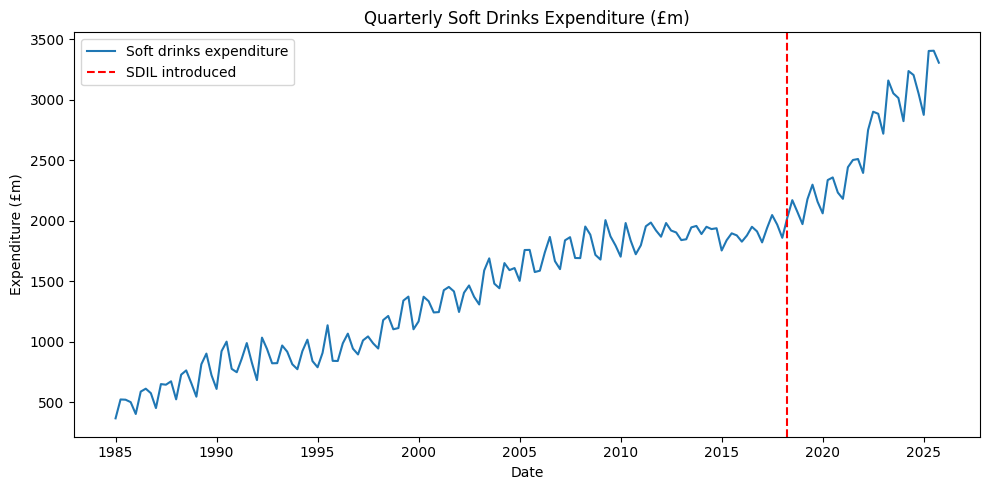

In [11]:

plt.figure(figsize=(10, 5))

plt.plot(
    df_q.index,
    df_q["soft_drinks_expenditure_m"],
    label="Soft drinks expenditure"
)
plt.axvline(pd.Timestamp("2018-04-01"), color="red", linestyle="--", label="SDIL introduced")

plt.title("Quarterly Soft Drinks Expenditure (£m)")
plt.xlabel("Date")
plt.ylabel("Expenditure (£m)")
plt.legend()

plt.tight_layout()
plt.show()


While Figure 1 shows a long run perspective, the length of time makes it difficult to assess behaviour immediately surrounding the introduction of SDIL. In particular, changes in slope or level around the policy date may be obscured by the strong upwards trend and seasonal variation present over the full sample. 

To examine the dynamics further, we present a zoomed in view focusing on the period before and after the SDIL was introduced. The narrower window will allow for clearer visual assessment of pre-policy trends and any deviations coinciding with the implementation of the levy. 

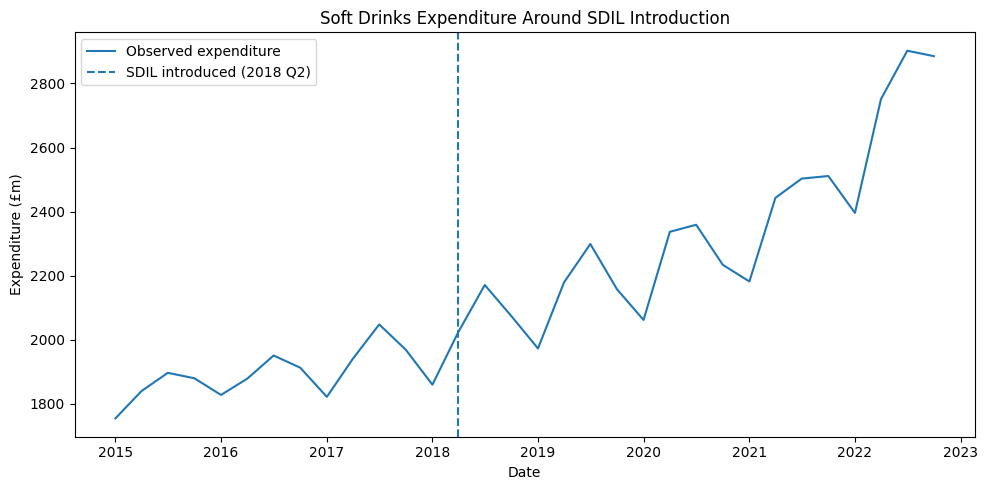

In [12]:
policy_date = pd.Timestamp("2018-04-01")

# Define zoom window
df_zoom = df_q.loc["2015-01-01":"2022-12-31"]

plt.figure(figsize=(10, 5))

plt.plot(
    df_zoom.index,
    df_zoom["soft_drinks_expenditure_m"],
    label="Observed expenditure",
)

plt.axvline(
    policy_date,
    linestyle="--",
    label="SDIL introduced (2018 Q2)"
)

plt.xlabel("Date")
plt.ylabel("Expenditure (£m)")
plt.title("Soft Drinks Expenditure Around SDIL Introduction")
plt.legend()

plt.tight_layout()
plt.show()

Figure 2 does not show any obvious visual change in trends. Expenditure seemingly continues to trend upwards with seasonal fluctuations. For this reason, the analysis continues by estimating and ITS, which formalises the pre-policy trend and tests for changes in the level or slope of expenditure. 

### ITS

The ITS model includes:
- a linear time trend (`t`)
- an indicator for the post-intervention period (`post`)
- an interaction term capturing a change in trend after the intervention (`t_post`)


In [13]:
df_q.loc["2017-01-01":"2019-12-31",
         ["soft_drinks_expenditure_m", "t", "post", "t_post"]]


KeyError: "['t', 'post', 't_post'] not in index"

In [ ]:

X = sm.add_constant(df_q[["t", "post", "t_post"]])
y = df_q["soft_drinks_expenditure_m"]

model = sm.OLS(y, X).fit()
print(model.summary())


In [ ]:

nw_model = model.get_robustcov_results(
    cov_type="HAC",
    maxlags=4   # quarterly data
)
print(nw_model.summary())
